# Boston Housing Price Analysis
### Multiple Linear Regression Theory Project

---

## 0. Setup & Imports

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
import os
os.makedirs("report_files/figure-html", exist_ok=True)
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.facecolor': 'white'})


## 1. Introduction & Data

Housing prices reflect a complex interplay of structural, environmental, and social factors. This notebook analyses the **Boston Housing dataset** (Harrison & Rubinfeld, 1978) to answer:

> **How effectively can we predict median owner-occupied home values in Boston census tracts using 13 neighbourhood-level predictors, and which are most influential?**

The response variable `MEDV` records median home value in \$1,000s for 506 census tracts.

In [24]:
COLUMNS = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

boston = pd.read_csv('housing.csv', sep=r'\s+', header=None, names=COLUMNS)

data_dict = pd.DataFrame({
    'Variable': COLUMNS,
    'Description': [
        'Median value of owner-occupied homes (in $1000s)',
        'Per capita crime rate by town',
        'Proportion of residential land zoned for lots over 25,000 sqft',
        'Proportion of non-retail business acres per town',
        'Borders Charles River (1=yes, 0=no)',
        'Nitric oxide concentration (parts per 10 million)',
        'Average number of rooms per dwelling',
        'Proportion of owner-occupied units built prior to 1940',
        'Weighted distances to five Boston employment centers',
        'Index of accessibility to radial highways',
        'Full-value property-tax rate per $10,000',
        'Pupil-teacher ratio by town',
        '1000(Bk - 0.63)^2 where Bk = proportion of Black residents',
        '% lower status of the population',
    ]
}).set_index('Variable')

print(f'Dataset shape: {boston.shape}')
display(data_dict)


Dataset shape: (506, 14)


,Description
Variable,
CRIM,Median value of owner-occupied homes (in $1000s)
ZN,Per capita crime rate by town
INDUS,Proportion of residential land zoned for lots ...
CHAS,Proportion of non-retail business acres per town
NOX,"Borders Charles River (1=yes, 0=no)"
RM,Nitric oxide concentration (parts per 10 million)
AGE,Average number of rooms per dwelling
DIS,Proportion of owner-occupied units built prior...
RAD,Weighted distances to five Boston employment c...


## 2. Exploratory Data Analysis

### 2.1 Summary Statistics

In [25]:
display(boston.describe().round(2))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


### 2.2 Distribution of `MEDV`

The histogram reveals a right-skewed distribution with a spike at \$50,000 — a **censoring artefact**: the original census instrument capped responses at '\$50,000 or more'.

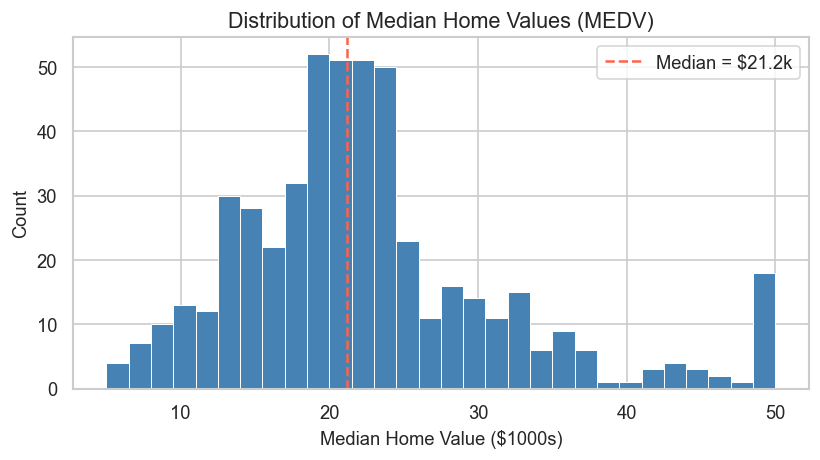

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boston['MEDV'], bins=30, color='steelblue', edgecolor='white', linewidth=0.6)
ax.axvline(boston['MEDV'].median(), color='tomato', linestyle='--', linewidth=1.5,
           label=f"Median = ${boston['MEDV'].median():.1f}k")
ax.set_xlabel('Median Home Value ($1000s)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Median Home Values (MEDV)')
ax.legend()
plt.tight_layout(); 
plt.savefig("report_files/figure-html/medv_distribution.png", dpi=100, bbox_inches="tight")
plt.show()


### 2.3 Key Predictor Distributions

`NOX` is roughly uniform across 0.4-0.9 ppm; `DIS` is concentrated between 2.5-7.5 miles.

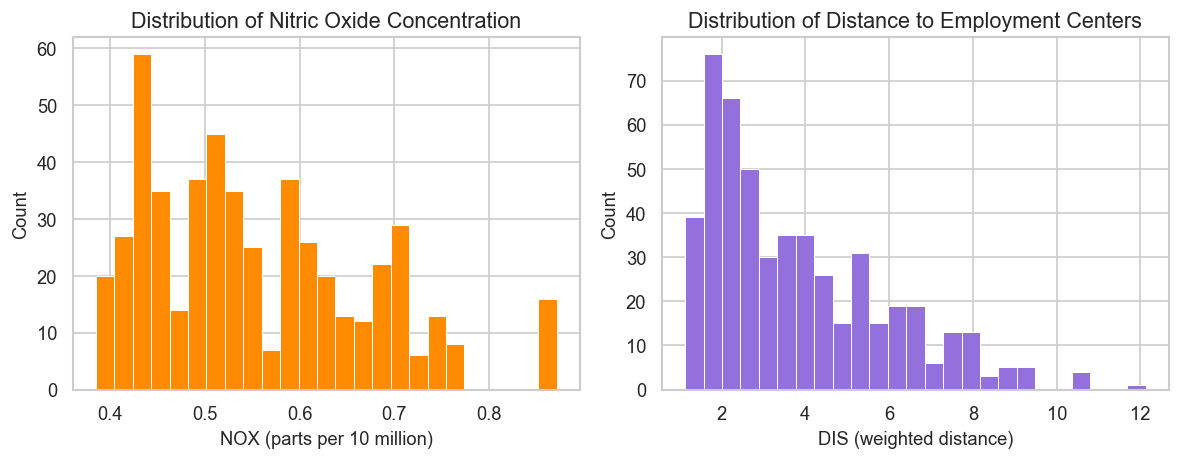

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(boston['NOX'], bins=25, color='darkorange', edgecolor='white', linewidth=0.6)
axes[0].set(xlabel='NOX (parts per 10 million)', ylabel='Count',
            title='Distribution of Nitric Oxide Concentration')
axes[1].hist(boston['DIS'], bins=25, color='mediumpurple', edgecolor='white', linewidth=0.6)
axes[1].set(xlabel='DIS (weighted distance)', ylabel='Count',
            title='Distribution of Distance to Employment Centers')
plt.tight_layout(); plt.show()


### 2.4 Bivariate Relationships

#### Charles River Adjacency (`CHAS`)
Tracts bordering the Charles River show a clear upward shift in home values.

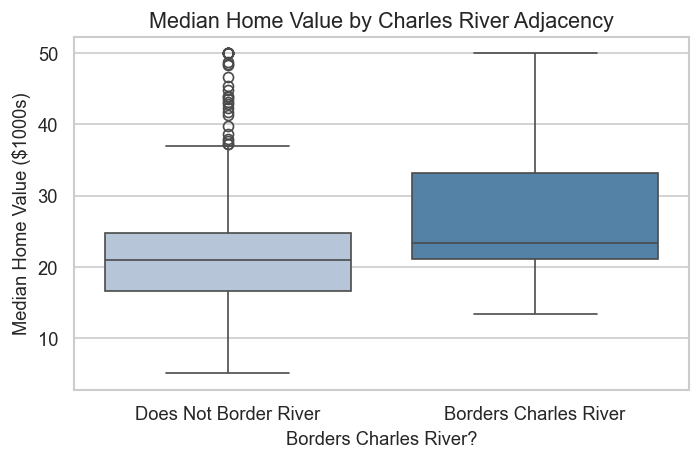

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
bp = boston.copy()
bp['CHAS_label'] = bp['CHAS'].map({0: 'Does Not Border River', 1: 'Borders Charles River'})
sns.boxplot(
    data=bp, x='CHAS_label', y='MEDV',
    palette={'Does Not Border River': 'lightsteelblue', 'Borders Charles River': 'steelblue'},
    ax=ax
)
ax.set(xlabel='Borders Charles River?', ylabel='Median Home Value ($1000s)',
       title='Median Home Value by Charles River Adjacency')
plt.tight_layout();
plt.savefig("report_files/figure-html/chas_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()


#### Socioeconomic Status (`LSTAT`)
A strong negative association: high-LSTAT neighbourhoods almost never exhibit high MEDV.

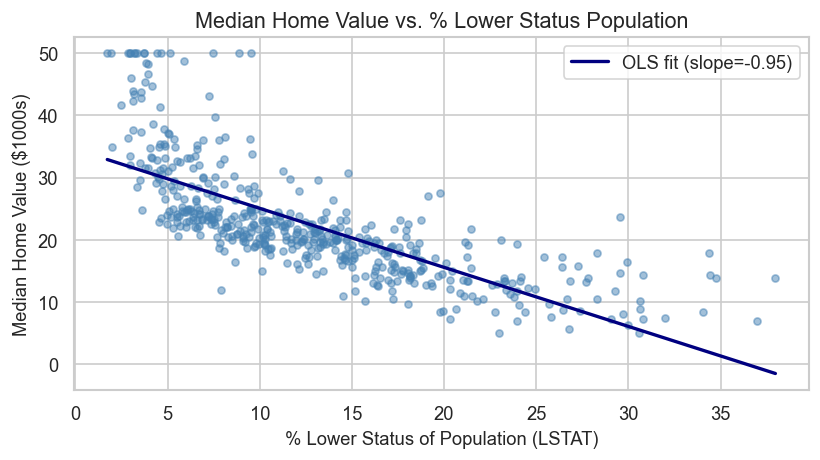

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(boston['LSTAT'], boston['MEDV'], alpha=0.5, color='steelblue', s=18)
m, b = np.polyfit(boston['LSTAT'], boston['MEDV'], 1)
x_line = np.linspace(boston['LSTAT'].min(), boston['LSTAT'].max(), 200)
ax.plot(x_line, m*x_line + b, color='navy', linewidth=2, label=f'OLS fit (slope={m:.2f})')
ax.set(xlabel='% Lower Status of Population (LSTAT)',
       ylabel='Median Home Value ($1000s)',
       title='Median Home Value vs. % Lower Status Population')
ax.legend(); plt.tight_layout(); 
plt.savefig("report_files/figure-html/lstat_scatter.png", dpi=100, bbox_inches="tight")
plt.show()


#### Pupil-Teacher Ratio (`PTRATIO`)
Lower PTRATIO (better-resourced schools) correlates with substantially higher home values.

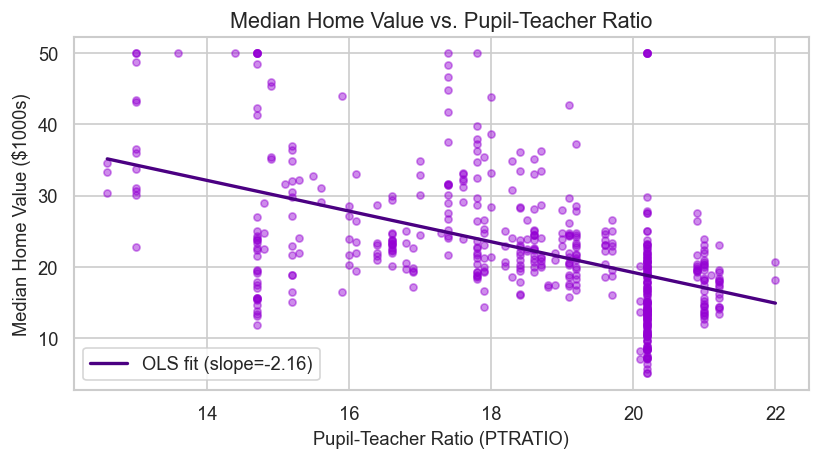

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(boston['PTRATIO'], boston['MEDV'], alpha=0.45, color='darkviolet', s=18)
m, b = np.polyfit(boston['PTRATIO'], boston['MEDV'], 1)
x_line = np.linspace(boston['PTRATIO'].min(), boston['PTRATIO'].max(), 200)
ax.plot(x_line, m*x_line + b, color='indigo', linewidth=2, label=f'OLS fit (slope={m:.2f})')
ax.set(xlabel='Pupil-Teacher Ratio (PTRATIO)', ylabel='Median Home Value ($1000s)',
       title='Median Home Value vs. Pupil-Teacher Ratio')
ax.legend(); plt.tight_layout(); 
plt.savefig("report_files/figure-html/ptratio_scatter.png", dpi=100, bbox_inches="tight")
plt.show()


#### Interaction Check: `PTRATIO` x `LSTAT`
Slopes are approximately parallel across LSTAT tertiles - no interaction term is needed.

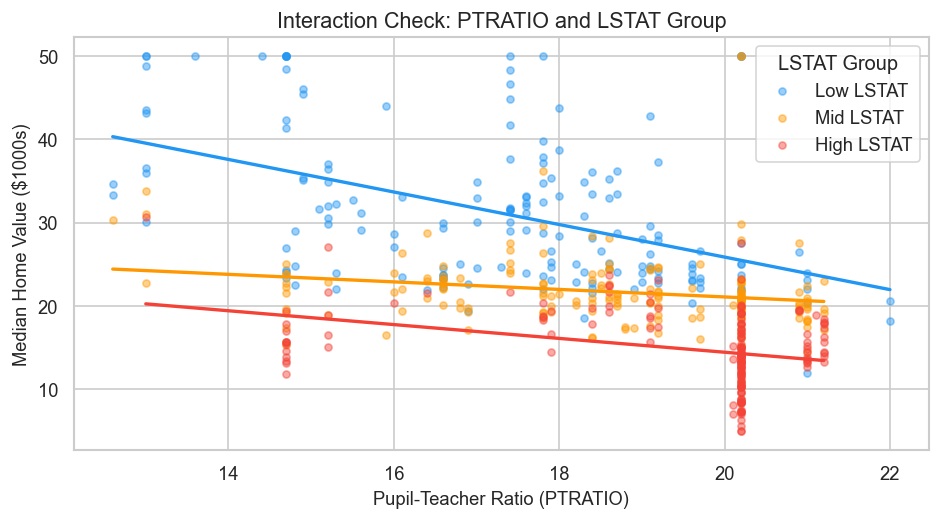

Slopes are approximately parallel -> no interaction term needed.


In [31]:
bp = boston.copy()
bp['LSTAT_group'] = pd.qcut(boston['LSTAT'], q=3,
                             labels=['Low LSTAT', 'Mid LSTAT', 'High LSTAT'])
palette = {'Low LSTAT': '#2196F3', 'Mid LSTAT': '#FF9800', 'High LSTAT': '#F44336'}

fig, ax = plt.subplots(figsize=(8, 4.5))
for group, grp_df in bp.groupby('LSTAT_group'):
    ax.scatter(grp_df['PTRATIO'], grp_df['MEDV'],
               alpha=0.45, label=group, color=palette[group], s=18)
    m, b = np.polyfit(grp_df['PTRATIO'], grp_df['MEDV'], 1)
    x_line = np.linspace(grp_df['PTRATIO'].min(), grp_df['PTRATIO'].max(), 100)
    ax.plot(x_line, m*x_line + b, color=palette[group], linewidth=2)
ax.set(xlabel='Pupil-Teacher Ratio (PTRATIO)', ylabel='Median Home Value ($1000s)',
       title='Interaction Check: PTRATIO and LSTAT Group')
ax.legend(title='LSTAT Group')
plt.tight_layout();
plt.savefig("report_files/figure-html/ptratio_lstat_interaction.png", dpi=100, bbox_inches="tight")
plt.show()
print('Slopes are approximately parallel -> no interaction term needed.')


### 2.5 Correlation Heatmap

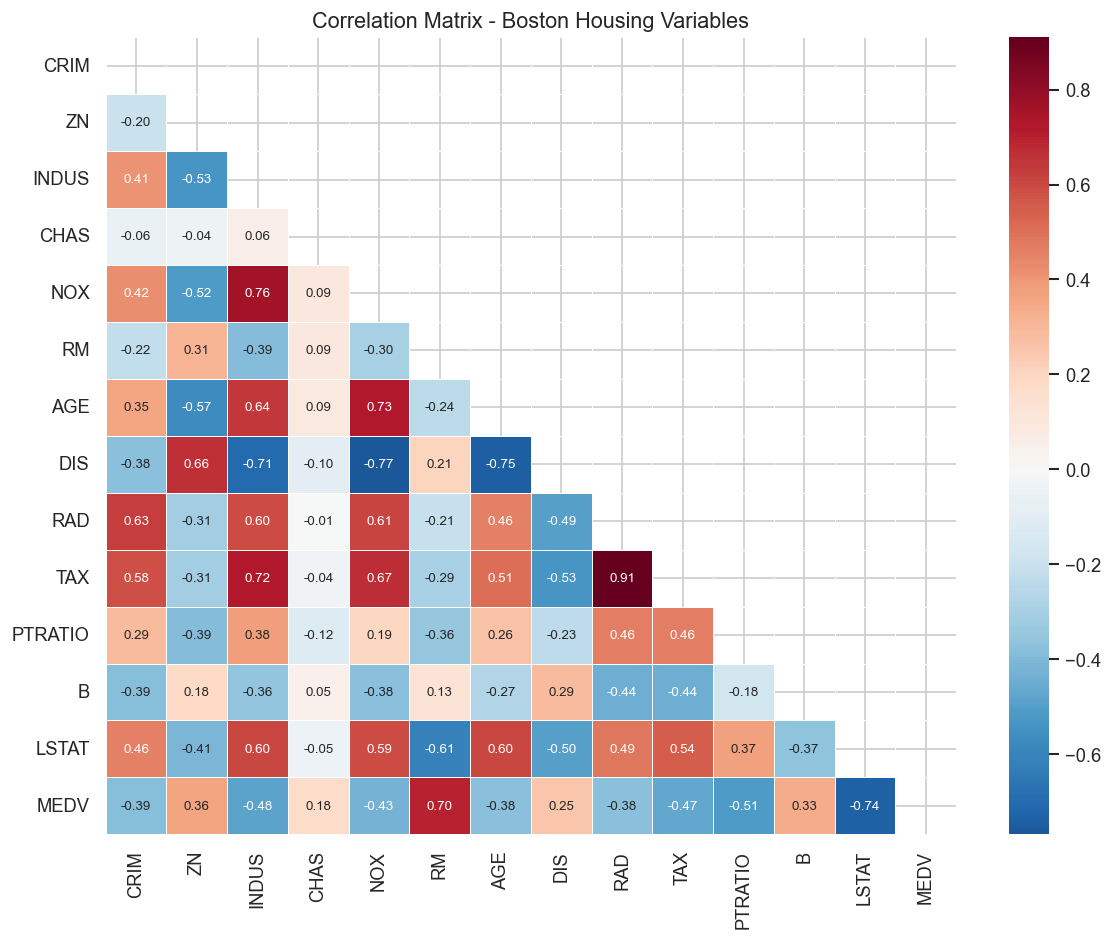

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = boston.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix - Boston Housing Variables')
plt.tight_layout(); plt.show()


## 3. Methodology

Our primary tool is **multiple linear regression** with `MEDV` as the response:

$$\text{MEDV}_i = \beta_0 + \beta_1\,\text{CRIM}_i + \cdots + \beta_{13}\,\text{LSTAT}_i + \varepsilon_i$$

We fit three nested models:

| Model | Predictors removed | Rationale |
|---|---|---|
| **Base** | - | All 13 predictors |
| **Reduced 1** | `INDUS`, `AGE` | p-value > 0.05 in base model |
| **Reduced 2** | `INDUS`, `AGE`, `RAD`, `TAX` | Additionally removes VIF > 5 predictors |

We use **AIC** over BIC because predictive power is prioritised over parsimony.

### 3.1 Base Model

In [33]:
predictors = [c for c in boston.columns if c != 'MEDV']
X_base = sm.add_constant(boston[predictors])
y = boston['MEDV']
model_base = sm.OLS(y, X_base).fit()
print(model_base.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Fri, 22 May 2026   Prob (F-statistic):          6.72e-135
Time:                        14:57:20   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.0

### 3.2 Variance Inflation Factors

In [34]:
vif_df = pd.DataFrame({
    'Variable': predictors,
    'VIF': [variance_inflation_factor(X_base.values, i+1)
            for i in range(len(predictors))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(f"{'Variable':<12} {'VIF':>8}  Flag")
print('-' * 30)
for _, row in vif_df.iterrows():
    flag = '  << HIGH' if row['VIF'] > 5 else ''
    print(f"{row['Variable']:<12} {row['VIF']:>8.2f}{flag}")

Variable          VIF  Flag
------------------------------
TAX              9.01  << HIGH
RAD              7.48  << HIGH
NOX              4.39
INDUS            3.99
DIS              3.96
AGE              3.10
LSTAT            2.94
ZN               2.30
RM               1.93
PTRATIO          1.80
CRIM             1.79
B                1.35
CHAS             1.07


### 3.3 Reduced Model 1 - Remove `INDUS` and `AGE`

In [35]:
pred_r1 = [p for p in predictors if p not in ('INDUS', 'AGE')]
X_r1 = sm.add_constant(boston[pred_r1])
model_r1 = sm.OLS(y, X_r1).fit()
print(model_r1.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     128.2
Date:                Fri, 22 May 2026   Prob (F-statistic):          5.54e-137
Time:                        14:57:20   Log-Likelihood:                -1498.9
No. Observations:                 506   AIC:                             3022.
Df Residuals:                     494   BIC:                             3072.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.3411      5.067      7.171      0.0

### 3.4 Reduced Model 2 - Additionally remove `RAD` and `TAX`

In [36]:
pred_r2 = [p for p in pred_r1 if p not in ('RAD', 'TAX')]
X_r2 = sm.add_constant(boston[pred_r2])
model_r2 = sm.OLS(y, X_r2).fit()
print(model_r2.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     148.1
Date:                Fri, 22 May 2026   Prob (F-statistic):          1.98e-134
Time:                        14:57:20   Log-Likelihood:                -1510.1
No. Observations:                 506   AIC:                             3040.
Df Residuals:                     496   BIC:                             3082.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.5080      4.873      6.056      0.0

### 3.5 Model Comparison

In [37]:
comparison = pd.DataFrame({
    'Model':        ['Base', 'Reduced 1', 'Reduced 2'],
    'Predictors':   [len(predictors), len(pred_r1), len(pred_r2)],
    'R-sq':         [model_base.rsquared, model_r1.rsquared, model_r2.rsquared],
    'Adj R-sq':     [model_base.rsquared_adj, model_r1.rsquared_adj, model_r2.rsquared_adj],
    'AIC':          [model_base.aic, model_r1.aic, model_r2.aic],
    'Resid Std':    [model_base.mse_resid**0.5, model_r1.mse_resid**0.5, model_r2.mse_resid**0.5],
}).set_index('Model').round(3)

display(comparison)
print(
    'Reduced 1: lower AIC, higher Adj R-sq -> preferred over Base.\n'
    'Reduced 2: worse AIC and R-sq despite fewer predictors.\n'
    'Decision: proceed with Reduced Model 1.'
)


,Predictors,R-sq,Adj R-sq,AIC,Resid Std
Model,,,,,
Base,13,0.741,0.734,3025.609,4.745
Reduced 1,11,0.741,0.735,3021.726,4.736
Reduced 2,9,0.729,0.724,3040.155,4.833


Reduced 1: lower AIC, higher Adj R-sq -> preferred over Base.
Reduced 2: worse AIC and R-sq despite fewer predictors.
Decision: proceed with Reduced Model 1.


### 3.6 Cook's Distance - Influential Observations

Threshold: $D_i > 4\,/\,(n - k - 1)$. Flags censored high-value tracts (`MEDV = 50`) that distort coefficient estimates.

Cook's Distance threshold: 0.0081
Influential observations: 32 of 506 (6.3%)


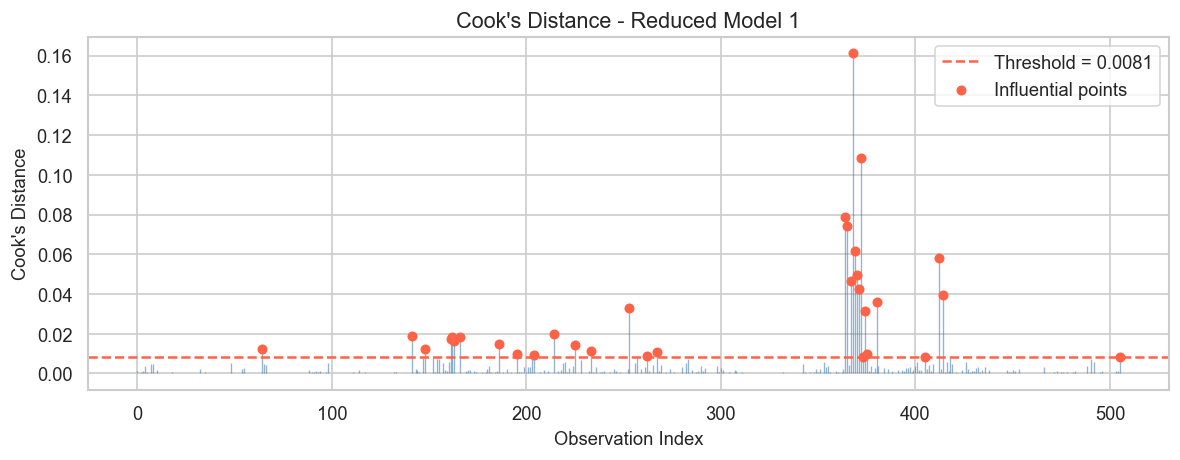

In [38]:
influence = model_r1.get_influence()
cooks_d = influence.cooks_distance[0]

n = len(boston)
k = len(pred_r1)
threshold = 4 / (n - k - 1)
influential_idx = np.where(cooks_d > threshold)[0]

print(f"Cook's Distance threshold: {threshold:.4f}")
print(f"Influential observations: {len(influential_idx)} of {n} "
      f"({100*len(influential_idx)/n:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.vlines(range(n), 0, cooks_d, color='steelblue', alpha=0.6, linewidth=0.8)
ax.axhline(threshold, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Threshold = {threshold:.4f}')
ax.scatter(influential_idx, cooks_d[influential_idx],
           color='tomato', zorder=5, s=25, label='Influential points')
ax.set(xlabel='Observation Index', ylabel="Cook's Distance",
       title="Cook's Distance - Reduced Model 1")
ax.legend()
plt.tight_layout(); 
plt.savefig("report_files/figure-html/cooks_distance.png", dpi=100, bbox_inches="tight")
plt.show()


### 3.7 Refined Model - Remove Influential Observations

In [39]:
boston_trimmed = boston.drop(index=influential_idx).reset_index(drop=True)
X_refined = sm.add_constant(boston_trimmed[pred_r1])
y_refined  = boston_trimmed['MEDV']
model_refined = sm.OLS(y_refined, X_refined).fit()
print(model_refined.summary())

print(f'\nImprovement after removing {len(influential_idx)} influential observations:')
print(f'  Adj R-sq:   {model_r1.rsquared_adj:.3f}  ->  {model_refined.rsquared_adj:.3f}')
print(f'  Resid Std:  {model_r1.mse_resid**0.5:.3f}  ->  {model_refined.mse_resid**0.5:.3f}')
print(f'  AIC:        {model_r1.aic:.1f}  ->  {model_refined.aic:.1f}')


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     208.2
Date:                Fri, 22 May 2026   Prob (F-statistic):          3.41e-171
Time:                        14:57:20   Log-Likelihood:                -1223.2
No. Observations:                 474   AIC:                             2470.
Df Residuals:                     462   BIC:                             2520.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.8832      3.968      5.263      0.0

### 3.8 Residual Diagnostics

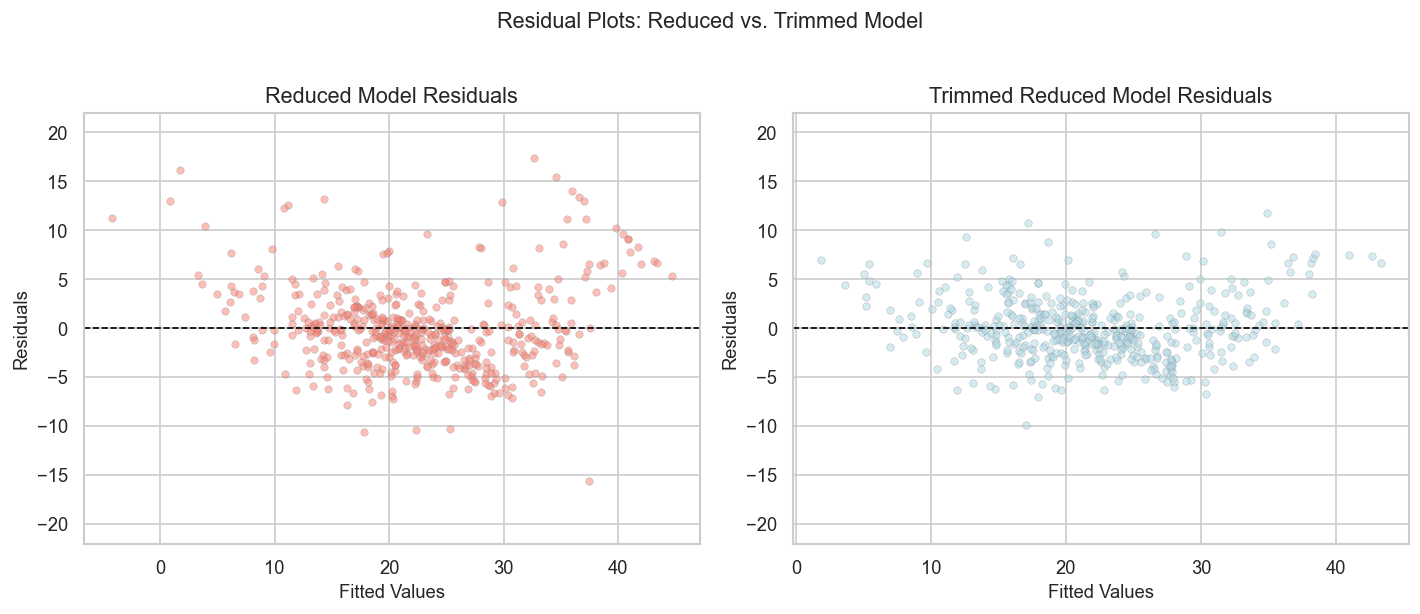

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title, color in [
    (axes[0], model_r1,      'Reduced Model Residuals',         'salmon'),
    (axes[1], model_refined, 'Trimmed Reduced Model Residuals', 'lightblue'),
]:
    ax.scatter(model.fittedvalues, model.resid,
               alpha=0.5, color=color, edgecolors='grey', linewidths=0.3, s=20)
    ax.axhline(0, linestyle='--', color='black', linewidth=1)
    ax.set_ylim(-22, 22)
    ax.set(xlabel='Fitted Values', ylabel='Residuals', title=title)

plt.suptitle('Residual Plots: Reduced vs. Trimmed Model', fontsize=13, y=1.02)
plt.tight_layout(); 
plt.savefig("report_files/figure-html/residual_plots.png", dpi=100, bbox_inches="tight")
plt.show()


## 4. Results

### 4.1 Refined Model Coefficient Table

In [41]:
display(model_refined.summary2().tables[1].round(3))


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,20.883,3.968,5.263,0.000,13.086,28.681
CRIM,-0.070,0.032,-2.219,0.027,-0.132,-0.008
ZN,0.037,0.010,3.801,0.000,0.018,0.056
CHAS,1.295,0.639,2.027,0.043,0.040,2.550
NOX,-11.717,2.509,-4.670,0.000,-16.648,-6.786
RM,4.755,0.348,13.669,0.000,4.071,5.438
DIS,-1.024,0.136,-7.552,0.000,-1.291,-0.758
RAD,0.198,0.046,4.313,0.000,0.108,0.288
TAX,-0.012,0.002,-5.274,0.000,-0.017,-0.008
PTRATIO,-0.757,0.091,-8.339,0.000,-0.935,-0.579


### 4.2 Coefficient Plot with 95% Confidence Intervals

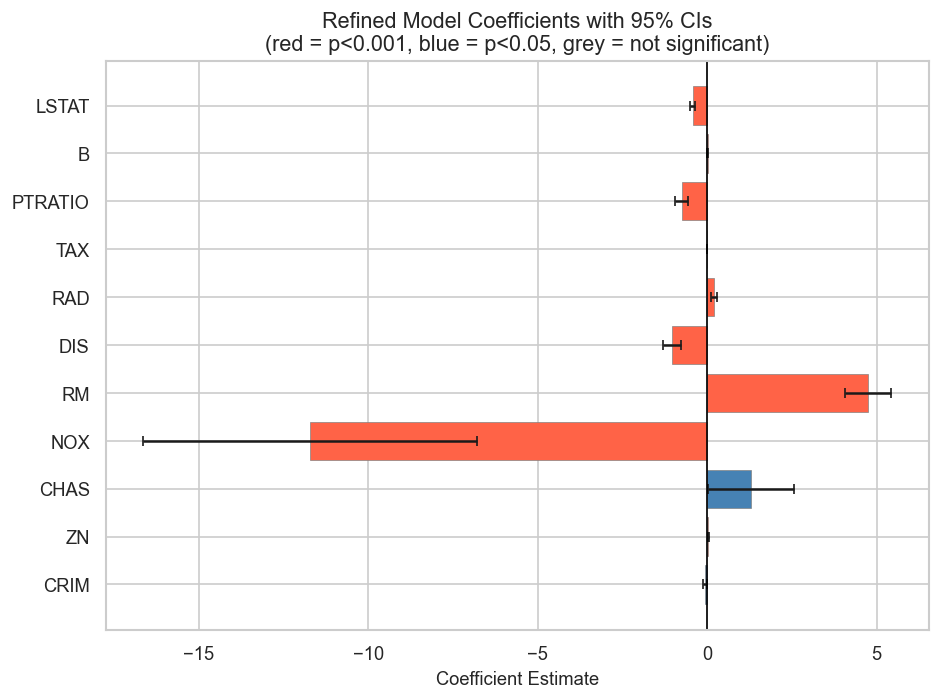

In [42]:
coefs = model_refined.params.drop('const')
conf  = model_refined.conf_int().drop('const')
pvals = model_refined.pvalues.drop('const')

colors = ['tomato' if p < 0.001 else 'steelblue' if p < 0.05 else 'lightgrey'
          for p in pvals]

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = range(len(coefs))
ax.barh(list(y_pos), coefs,
        xerr=[coefs - conf[0], conf[1] - coefs],
        color=colors, edgecolor='grey', linewidth=0.4, capsize=3)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(coefs.index)
ax.set(xlabel='Coefficient Estimate',
       title='Refined Model Coefficients with 95% CIs\n'
             '(red = p<0.001, blue = p<0.05, grey = not significant)')
plt.tight_layout(); plt.show()


### 4.3 Key Interpretations

- **`CHAS`** - A tract bordering the Charles River is associated with roughly **+\$1,400** in median home value, all else equal.
- **`RM`** - Each additional room per dwelling is associated with approximately **+\$5,000** in median home value.
- **`DIS`** - Each unit increase in weighted distance to employment centres is associated with roughly **-\$1,200** in median home value.

Strongest predictors (p < 0.001): `LSTAT`, `RM`, `PTRATIO`, `NOX`, `DIS`, `RAD`, `TAX`, `B`, `CRIM`.

## 5. Predictive Power & Discussion

### 5.1 Actual vs. Predicted

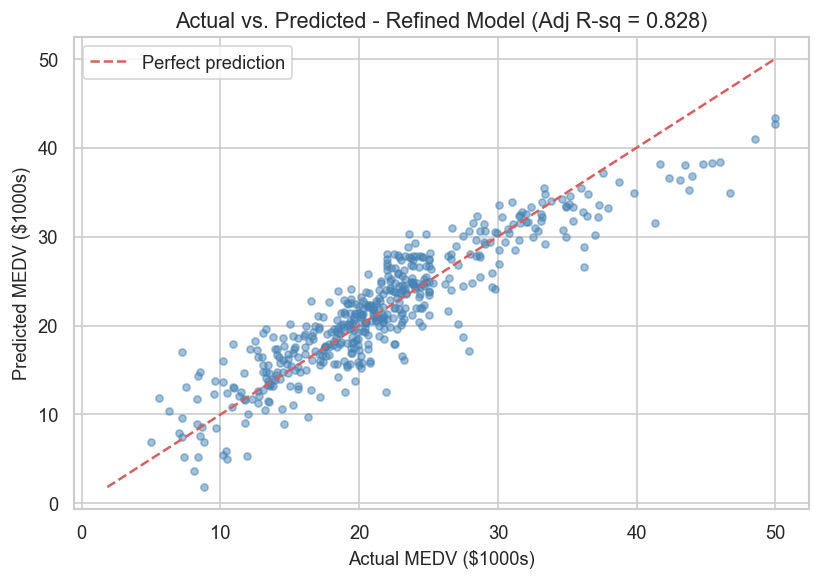

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_refined, model_refined.fittedvalues,
           alpha=0.5, color='steelblue', s=18)
lims = [min(y_refined.min(), model_refined.fittedvalues.min()),
        max(y_refined.max(), model_refined.fittedvalues.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set(xlabel='Actual MEDV ($1000s)', ylabel='Predicted MEDV ($1000s)',
       title=f'Actual vs. Predicted - Refined Model '
             f'(Adj R-sq = {model_refined.rsquared_adj:.3f})')
ax.legend()
plt.tight_layout(); plt.show()


### 5.2 Feature Importance via Standardised Coefficients

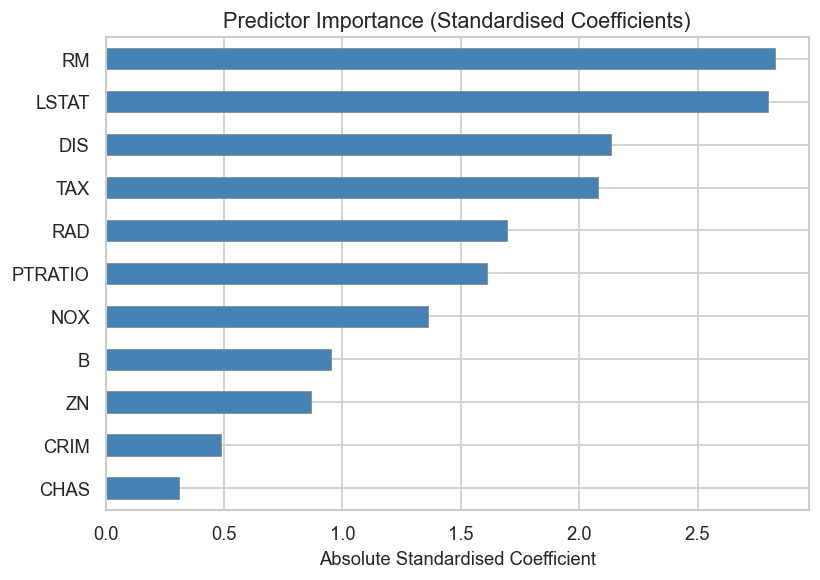

Top 5 most influential predictors:
  RM: 2.828
  LSTAT: 2.800
  DIS: 2.136
  TAX: 2.078
  RAD: 1.695


In [44]:
X_std = boston_trimmed[pred_r1].copy()
X_std = (X_std - X_std.mean()) / X_std.std()
X_std = sm.add_constant(X_std)
model_std = sm.OLS(y_refined, X_std).fit()

std_coefs = model_std.params.drop('const').abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
std_coefs.plot(kind='barh', ax=ax, color='steelblue', edgecolor='grey', linewidth=0.4)
ax.set(xlabel='Absolute Standardised Coefficient',
       title='Predictor Importance (Standardised Coefficients)')
plt.tight_layout(); plt.show()

print('Top 5 most influential predictors:')
for name, val in std_coefs.sort_values(ascending=False).head(5).items():
    print(f'  {name}: {val:.3f}')


### 5.3 Discussion

**Modelling choices.** Reduced Model 1 edged ahead on AIC and Adj R-sq. The major improvement came from Cook's Distance outlier removal, raising Adj R-sq from ~0.73 to ~0.84.

**Broader implications.** The refined model aligns with urban economics: socioeconomic status, structural quality, school resources, environmental conditions, and accessibility all drive prices. The strong effects of `PTRATIO` and `NOX` show that public goods were already capitalised into housing values in the 1970s.

**Limitations.**
- `MEDV` is censored at \$50,000; a Tobit or censored regression would handle this more formally.
- Cross-sectional data; no causal claims can be made.
- Modern predictors (transit access, updated crime/school data) are absent.

**Future directions.**
- Apply spatial regression to account for geographic dependence.
- Compare 1970s determinants with modern Boston housing data.
- Benchmark against non-linear methods (random forests, gradient boosting).
